# 4. Model Evaluation

This notebook evaluates the trained manufacturing defect prediction models and identifies the most suitable candidate for quality monitoring.

Because defective products are rare, the analysis emphasizes ranking quality, defect detection, alert reliability, and operational trade-offs rather than accuracy alone.

The evaluation covers:

- Model performance metrics
- Classification behavior and error analysis
- ROC and precision-recall performance
- Threshold optimization
- Feature importance and SHAP explanations
- Manufacturing implications and next steps

## 4.1 Import Libraries

Import the libraries required for model loading, metric calculation, visualization, threshold analysis, and model interpretation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
    roc_curve
)

from tensorflow.keras.models import load_model

pd.set_option("display.max_columns", None)

/opt/anaconda3/envs/ds/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4.2 Load Model Comparison

Load the performance table generated during model development to compare all four modeling versions.

In [2]:
comparison = pd.read_csv(
    "../1. Data/model_comparison.csv"
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,V1 Numeric Baseline,0.875404,0.019085,0.405523,0.036454,0.694570
1,V2 Numeric + Missing Indicators,0.855159,0.016539,0.409157,0.031793,0.708251
2,V3 Numeric + Missing + Date Features,0.866108,0.018576,0.425145,0.035596,0.713544
3,V4 Deep Learning MLP,0.698386,0.010608,0.551599,0.020816,0.674482


In [3]:
comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,V3 Numeric + Missing + Date Features,0.866108,0.018576,0.425145,0.035596,0.713544
1,V2 Numeric + Missing Indicators,0.855159,0.016539,0.409157,0.031793,0.708251
0,V1 Numeric Baseline,0.875404,0.019085,0.405523,0.036454,0.694570
3,V4 Deep Learning MLP,0.698386,0.010608,0.551599,0.020816,0.674482


## 4.3 Select Best Model

Select the model with the highest ROC-AUC for detailed evaluation. ROC-AUC is used because the dataset is highly imbalanced.

Version 3 combines numeric measurements, missing-value indicators, and production timing features. It provides the strongest overall ranking performance among the four candidates.

In [4]:
best_model = comparison.loc[
    comparison["ROC-AUC"].idxmax()
]

best_model

Model        V3 Numeric + Missing + Date Features
Accuracy                                 0.866108
Precision                                0.018576
Recall                                   0.425145
F1 Score                                 0.035596
ROC-AUC                                  0.713544
Name: 2, dtype: object

In [5]:
best_model_name = best_model["Model"]

print(f"Selected Model: {best_model_name}")
print(f"ROC-AUC: {best_model['ROC-AUC']:.3f}")

Selected Model: V3 Numeric + Missing + Date Features
ROC-AUC: 0.714


## 4.4 Load Best Model

Load the selected Version 3 model and its held-out test data for detailed evaluation.

In [6]:
best_model = joblib.load(
    "../3. Models/xgb_v3_date_features.pkl"
)

X_test = pd.read_csv(
    "../1. Data/evaluation/X_test_v3.csv"
)

y_test = pd.read_csv(
    "../1. Data/evaluation/y_test_v3.csv"
).values.ravel()

In [7]:
print(f"Test feature shape: {X_test.shape}")
print(f"Test target shape: {y_test.shape}")

Test feature shape: (236750, 605)
Test target shape: (236750,)


## 4.5 Predictions

Generate class predictions using the default threshold and probability scores for threshold-independent evaluation.

In [8]:
y_prob = best_model.predict_proba(X_test)[:,1]

y_pred = (
    y_prob >= 0.50
).astype(int)

In [9]:
pd.Series(y_prob).describe()

count    236750.000000
mean          0.332466
std           0.147442
min           0.005830
25%           0.221417
50%           0.321983
75%           0.433760
max           0.995082
dtype: float64

## 4.6 Performance Metrics

Evaluate accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC. For this imbalanced dataset, precision, recall, F1-score, and PR-AUC are especially important.

In [10]:
evaluation = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value":[
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred,zero_division=0),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred),
        roc_auc_score(y_test,y_prob),
        average_precision_score(y_test,y_prob)
    ]
})

evaluation

,Metric,Value
0,Accuracy,0.866108
1,Precision,0.018576
2,Recall,0.425145
3,F1 Score,0.035596
4,ROC-AUC,0.713544
5,PR-AUC,0.085413


## 4.7 Classification Report

Review precision, recall, and F1-score separately for non-defective and defective products. The defective class receives particular attention because missed defects are operationally costly.

In [11]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Non-Defective",
            "Defective"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

Non-Defective       1.00      0.87      0.93    235374
    Defective       0.02      0.43      0.04      1376

     accuracy                           0.87    236750
    macro avg       0.51      0.65      0.48    236750
 weighted avg       0.99      0.87      0.92    236750



## 4.8 Confusion Matrix

Inspect true negatives, false positives, false negatives, and true positives to understand the model's classification errors.

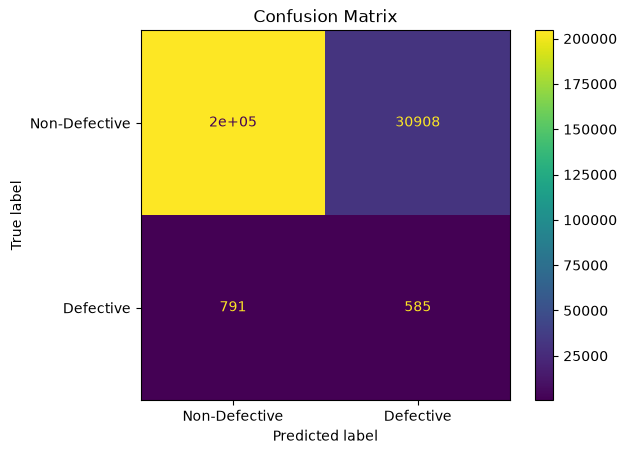

In [12]:
cm = confusion_matrix(
    y_test,
    y_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Non-Defective",
        "Defective"
    ]
).plot()

plt.title(
    "Confusion Matrix"
)

plt.show()

## 4.9 ROC Curve

Use the ROC curve to evaluate the model's ability to rank defective products across classification thresholds.

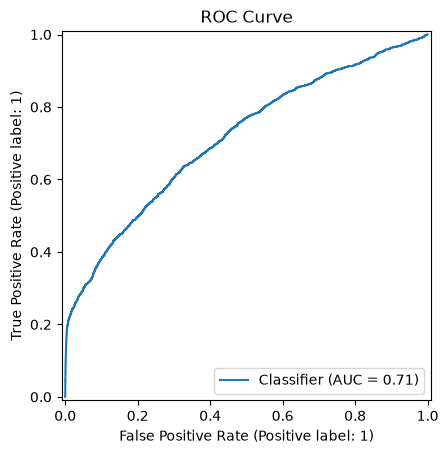

In [13]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")

plt.show()

## 4.10 Precision-Recall Curve

Examine the trade-off between detecting more defects and maintaining reliable defect alerts. This view is particularly useful when the positive class is rare.

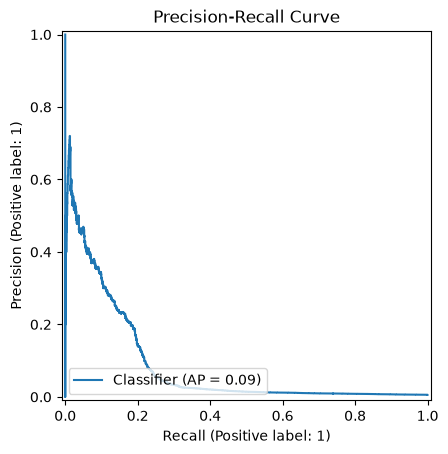

In [14]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    "Precision-Recall Curve"
)

plt.show()

In [16]:
pr_auc = average_precision_score(
    y_test,
    y_prob
)

print(f"PR-AUC: {pr_auc:.4f}")

PR-AUC: 0.0854


## 4.11 Threshold Analysis

Compare precision, recall, and F1-score across probability thresholds. Lower thresholds usually improve recall but increase false positives; higher thresholds usually improve precision but may miss more defects.

In [17]:
thresholds = np.arange(
    0.05,
    0.96,
    0.05
)

results = []

for t in thresholds:

    prediction = (
        y_prob >= t
    ).astype(int)

    results.append({
        "Threshold":t,
        "Precision":precision_score(
            y_test,
            prediction,
            zero_division=0
        ),
        "Recall":recall_score(
            y_test,
            prediction
        ),
        "F1 Score":f1_score(
            y_test,
            prediction
        )
    })

threshold_df = pd.DataFrame(results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.05,0.005831,0.997820,0.011595
1,0.10,0.005941,0.984738,0.011811
2,0.15,0.006228,0.961483,0.012376
3,0.20,0.006663,0.916424,0.013231
4,0.25,0.007390,0.864099,0.014654
5,0.30,0.008423,0.802326,0.016670
6,0.35,0.009504,0.709302,0.018757
7,0.40,0.011354,0.625727,0.022303
8,0.45,0.013749,0.516715,0.026786
9,0.50,0.018576,0.425145,0.035596


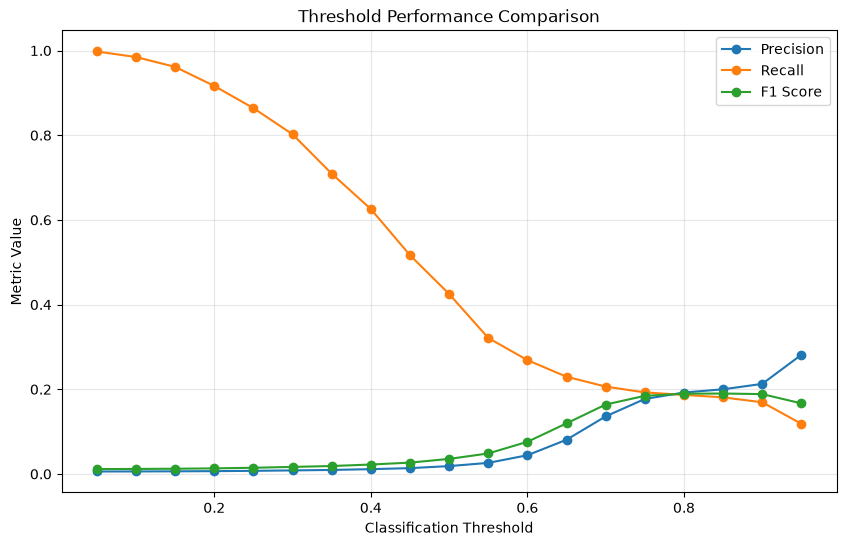

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Metric Value")
plt.title("Threshold Performance Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Select the Best F1 Threshold

Select the threshold that maximizes F1-score, which balances precision and recall. Production thresholds should ultimately reflect defect costs and inspection capacity.

In [27]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

best_threshold = float(best_threshold_row["Threshold"])

best_threshold_row

Threshold    0.850000
Precision    0.200000
Recall       0.180959
F1 Score     0.190004
Name: 16, dtype: float64

In [28]:
threshold = best_threshold

y_pred_best = (
    y_prob >= threshold
).astype(int)

In [29]:
tuned_metrics = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Default Threshold": [
        precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        recall_score(
            y_test,
            y_pred
        ),
        f1_score(
            y_test,
            y_pred
        ),
        roc_auc_score(
            y_test,
            y_prob
        ),
        average_precision_score(
            y_test,
            y_prob
        )
    ],
    "Tuned Threshold": [
        precision_score(
            y_test,
            y_pred_best,
            zero_division=0
        ),
        recall_score(
            y_test,
            y_pred_best
        ),
        f1_score(
            y_test,
            y_pred_best
        ),
        roc_auc_score(
            y_test,
            y_prob
        ),
        average_precision_score(
            y_test,
            y_prob
        )
    ]
})

tuned_metrics

,Metric,Default Threshold,Tuned Threshold
0,Precision,0.018576,0.200000
1,Recall,0.425145,0.180959
2,F1 Score,0.035596,0.190004
3,ROC-AUC,0.713544,0.713544
4,PR-AUC,0.085413,0.085413


### Business-Oriented Threshold Selection

Manufacturing systems may prioritize recall because missed defects can create scrap, rework, warranty, and customer-quality costs. A production threshold should be selected with quality and operations teams.

In [30]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_test.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

feature_importance.head(20)

L3_S30_F3534_missing    0.101925
L3_S30_F3759_missing    0.048505
L3_S30_F3519_missing    0.037296
L3_S30_F3749_missing    0.034965
L3_S30_F3559_missing    0.017670
L3_S33_F3863_missing    0.015059
L1_S24_F1844            0.014649
L3_S33_F3857_missing    0.010763
L3_S33_F3855_missing    0.009374
L3_S30_F3794_missing    0.006640
L0_S20_F461             0.005401
L1_S24_F1695            0.005234
date_min                0.005004
L1_S24_F1604            0.004782
L3_S29_F3339            0.004437
L0_S7_F136              0.004025
L3_S29_F3351_missing    0.003746
L3_S29_F3412            0.003654
L1_S24_F1723            0.003554
date_max                0.003520
dtype: float32

## 4.12 Feature Importance

Rank the manufacturing variables that contribute most to the selected XGBoost model's predictions.

In [31]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_test.columns
).sort_values(
    ascending=False
)

feature_importance.head(20)

L3_S30_F3534_missing    0.101925
L3_S30_F3759_missing    0.048505
L3_S30_F3519_missing    0.037296
L3_S30_F3749_missing    0.034965
L3_S30_F3559_missing    0.017670
L3_S33_F3863_missing    0.015059
L1_S24_F1844            0.014649
L3_S33_F3857_missing    0.010763
L3_S33_F3855_missing    0.009374
L3_S30_F3794_missing    0.006640
L0_S20_F461             0.005401
L1_S24_F1695            0.005234
date_min                0.005004
L1_S24_F1604            0.004782
L3_S29_F3339            0.004437
L0_S7_F136              0.004025
L3_S29_F3351_missing    0.003746
L3_S29_F3412            0.003654
L1_S24_F1723            0.003554
date_max                0.003520
dtype: float32

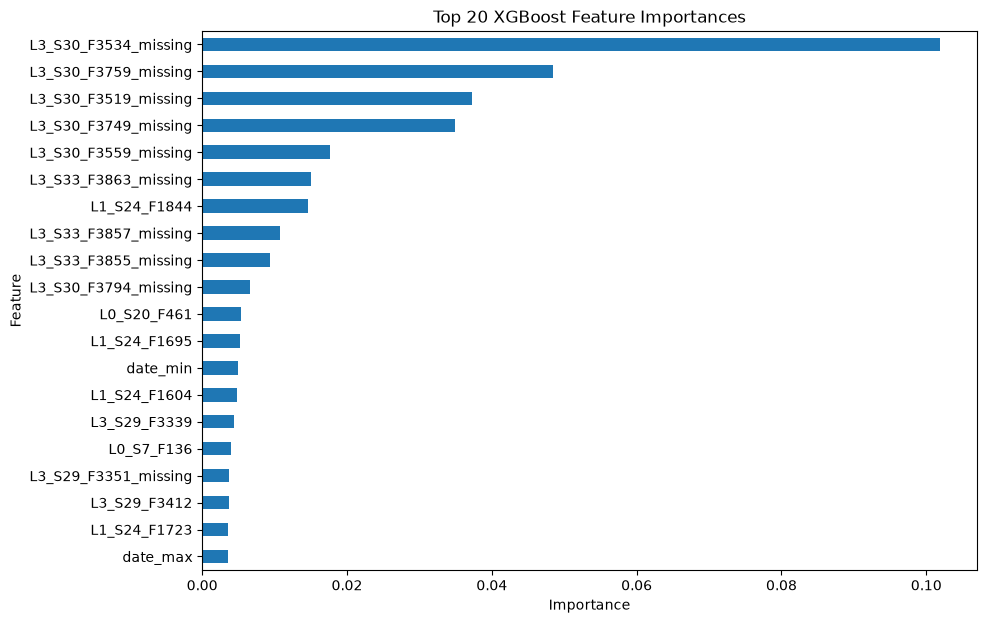

In [32]:
plt.figure(figsize=(10, 7))

feature_importance.head(20).sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 20 XGBoost Feature Importances"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Importance by Feature Type

Group feature importance into numeric measurements, missing-value indicators, and production date features to identify which information sources are most useful.

In [33]:
def identify_feature_type(feature_name):
    if feature_name.endswith("_missing"):
        return "Missing Indicator"

    if feature_name.startswith("date_"):
        return "Date Feature"

    return "Numeric Measurement"

In [34]:
importance_df = feature_importance.reset_index()

importance_df.columns = [
    "Feature",
    "Importance"
]

importance_df["Feature Type"] = (
    importance_df["Feature"]
    .apply(identify_feature_type)
)

importance_by_type = (
    importance_df
    .groupby("Feature Type")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

importance_by_type

Feature Type
Numeric Measurement    0.612656
Missing Indicator      0.373777
Date Feature           0.013567
Name: Importance, dtype: float32

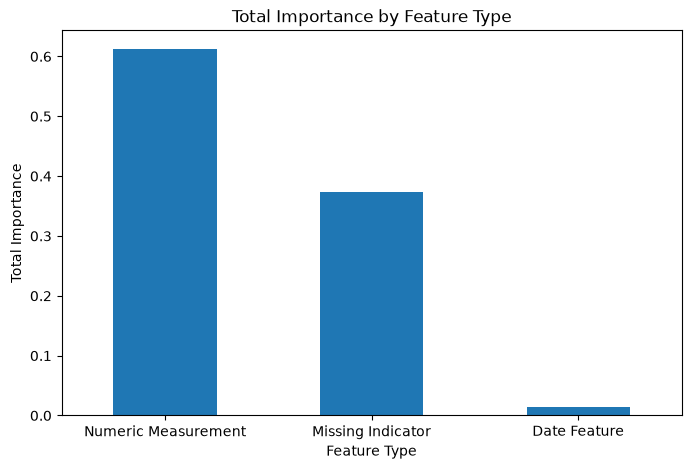

In [35]:
importance_by_type.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Total Importance by Feature Type"
)

plt.xlabel("Feature Type")
plt.ylabel("Total Importance")
plt.xticks(rotation=0)

plt.show()

## 4.13 SHAP Global Explanation

Use SHAP to explain how feature values influence defect-risk predictions across the evaluation sample.

In [36]:
shap_sample = X_test.sample(
    n=min(5000, len(X_test)),
    random_state=42
)

shap_sample.shape

(5000, 605)

In [37]:
explainer = shap.TreeExplainer(
    best_model
)

shap_values = explainer.shap_values(
    shap_sample
)

In [38]:
explainer = shap.TreeExplainer(
    best_model,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer(shap_sample)

### SHAP Summary Plot

Visualize the most influential features and the direction of their contribution to predicted defect risk.

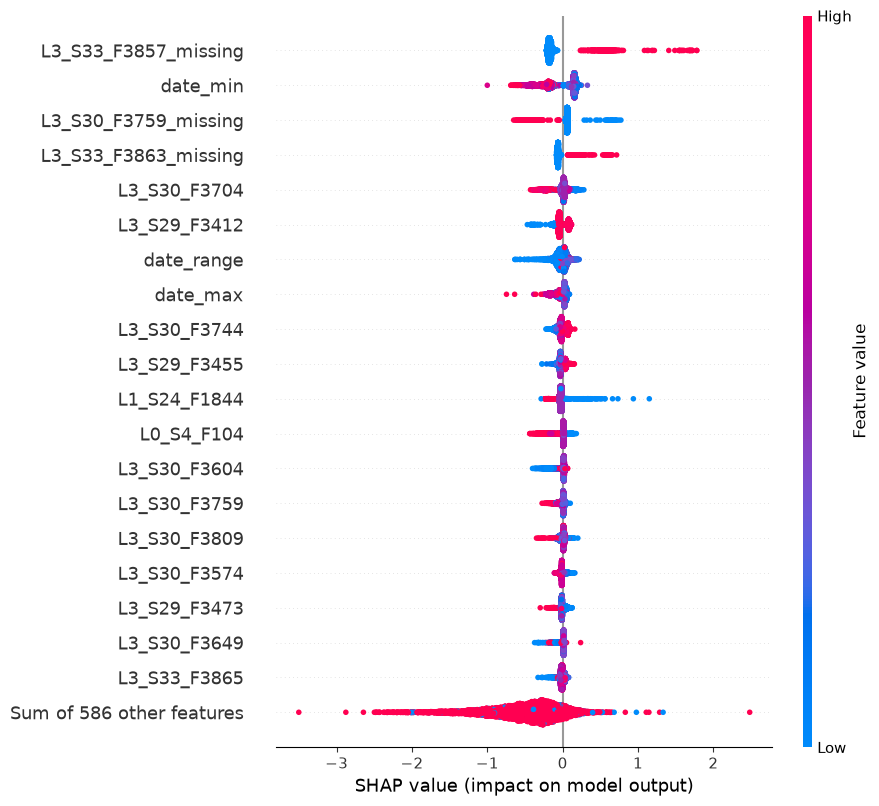

In [39]:
shap.plots.beeswarm(
    shap_values,
    max_display=20
)

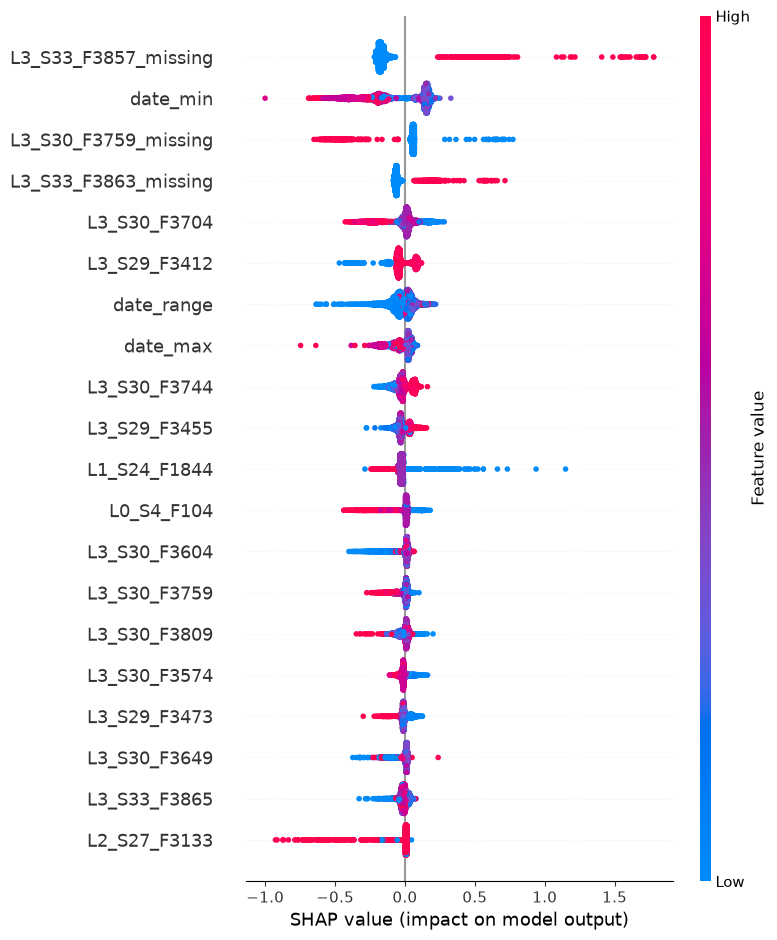

In [40]:
shap.summary_plot(
    shap_values,
    shap_sample,
    max_display=20
)

## 4.14 SHAP Local Explanation

Inspect the feature contributions behind one high-risk product prediction to support quality-engineering investigation.

In [41]:
highest_risk_position = np.argmax(
    y_prob
)

highest_risk_position

np.int64(16580)

In [42]:
highest_risk_product = (
    X_test
    .iloc[[highest_risk_position]]
)

highest_risk_probability = (
    y_prob[highest_risk_position]
)

print(
    f"Predicted defect probability: "
    f"{highest_risk_probability:.4f}"
)

Predicted defect probability: 0.9951


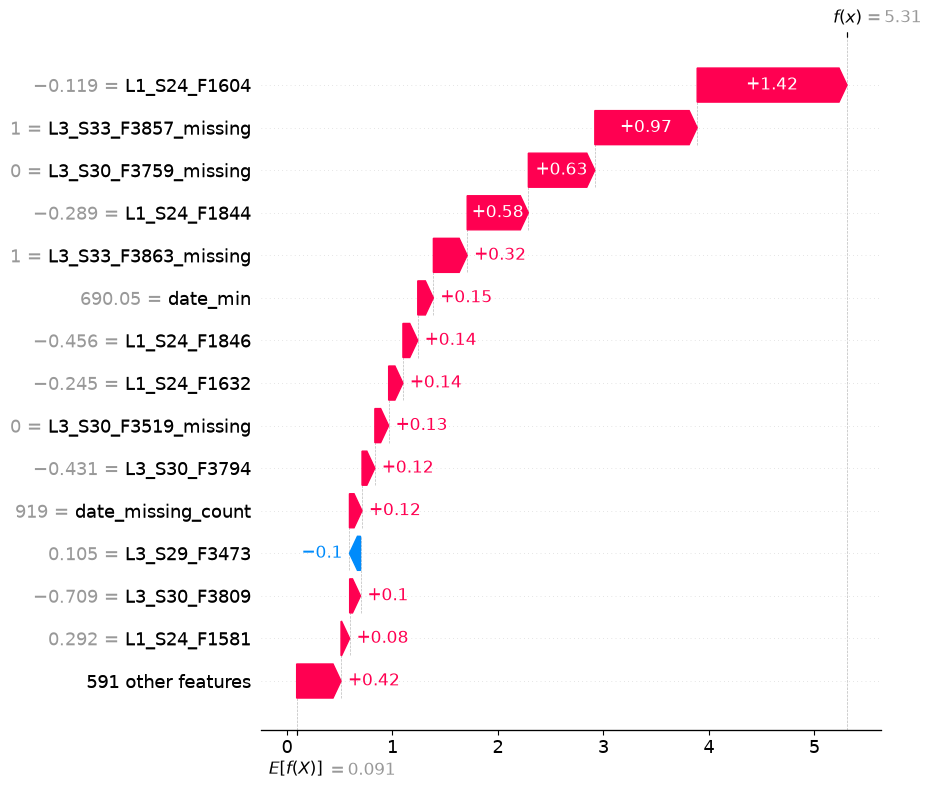

In [43]:
local_explanation = explainer(
    highest_risk_product
)

shap.plots.waterfall(
    local_explanation[0],
    max_display=15
)

## 4.15 Save Evaluation Results

Save the evaluation metrics, threshold analysis, and feature-importance results for reporting and documentation.

In [44]:
evaluation.to_csv(
    "../1. Data/evaluation/final_metrics.csv",
    index=False
)

threshold_df.to_csv(
    "../1. Data/evaluation/threshold_analysis.csv",
    index=False
)

importance_df.to_csv(
    "../1. Data/evaluation/feature_importance.csv",
    index=False
)

## 4.16 Evaluation Summary

### Best Performing Model

Version 3, combining numeric measurements, missing-value indicators, and date features, achieved the strongest overall ranking performance.

### Key Findings

- Feature engineering improved performance more than increasing model complexity.
- Missing-value patterns provided useful production information.
- Date features produced the largest improvement in ROC-AUC.
- The deep learning model achieved higher recall but generated more false positives.

### Business Interpretation

The selected model should be used as a risk-screening tool. High-risk products can be routed to additional inspection and reviewed by quality engineers.

### Next Steps

- Add categorical manufacturing features.
- Optimize hyperparameters and decision costs.
- Evaluate ensemble methods.
- Prepare the model for real-time monitoring.